<a href="https://colab.research.google.com/github/Moaazhe74/CIFAR10-Deep-Learning-Portfolio/blob/main/CIFAR10_(Deep_Learning_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Project Introduction***

This project applies different Deep Learning techniques to the CIFAR-10 image dataset.  
The objective is to build a complete Deep Learning portfolio that includes image classification, optimizer comparison, image reconstruction, and image generation.

The project consists of three main parts:

1. **Image Classification**
   - Build a Convolutional Neural Network (CNN) to classify CIFAR-10 images into 10 different classes.
   - Train the same CNN architecture using different optimizers.
   - Compare the performance of Adam and SGD with Momentum.

2. **Image Reconstruction**
   - Build a Convolutional Autoencoder or Variational Autoencoder.
   - Compress the input images into a latent representation.
   - Reconstruct the original images and evaluate the reconstruction quality.

3. **Image Generation**
   - Use a generative model such as a Variational Autoencoder or GAN.
   - Generate new images similar to the CIFAR-10 dataset.
   - Compare original, reconstructed, and generated images.

The models will be evaluated using training loss, validation loss, accuracy, reconstruction loss, and visual inspection of the generated images.

---

## Dataset

The **CIFAR-10 dataset** contains 60,000 colored images with a size of `32 × 32` pixels.

The dataset is divided into:

- 50,000 training images.
- 10,000 testing images.
- 10 different image classes.

The classes are:

`Airplane`, `Automobile`, `Bird`, `Cat`, `Deer`, `Dog`, `Frog`, `Horse`, `Ship`, and `Truck`.

# ***2. Imports and Setup***

In [8]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tarfile
import pickle

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# ***3. Load CIFAR-10 Dataset***

In [7]:
DataSetGoogleDrivePath = '/content/drive/MyDrive/DataSets/cifar-10-python.tar.gz'

extract_dir = "/content/drive/MyDrive/DataSets"

dataset_dir = os.path.join(
    extract_dir,
    "cifar-10-batches-py"
)

if os.path.exists(dataset_dir):
    print("Dataset is already extracted.")
    print("Dataset directory:", dataset_dir)

else:
    print("Extracting CIFAR-10 dataset...")

    with tarfile.open(DataSetGoogleDrivePath, mode="r:gz") as tar:
        tar.extractall(path=extract_dir)

    print("Dataset extracted successfully.")
    print("Dataset directory:", dataset_dir)

Extracting CIFAR-10 dataset...
Dataset extracted successfully.
Dataset directory: /content/drive/MyDrive/DataSets/cifar-10-batches-py


In [9]:
def load_cifar_batch(file_path):

    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = batch[b"labels"]


    images = images.reshape(-1, 3, 32, 32)


    images = images.transpose(0, 2, 3, 1)


    labels = np.array(labels).reshape(-1, 1)

    return images, labels



In [10]:
train_images = []
train_labels = []

for batch_number in range(1, 6):

    batch_path = os.path.join(
        dataset_dir,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    train_images.append(images)
    train_labels.append(labels)

    print(
        f"Batch {batch_number} loaded:",
        images.shape,
        labels.shape
    )
x_train = np.concatenate(train_images, axis=0)
y_train = np.concatenate(train_labels, axis=0)



test_batch_path = os.path.join(dataset_dir,"test_batch")
x_test, y_test = load_cifar_batch(test_batch_path)

Batch 1 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 2 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 3 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 4 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 5 loaded: (10000, 32, 32, 3) (10000, 1)


In [11]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [12]:
print("\nImage data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())


Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [13]:
meta_path = os.path.join(dataset_dir, "batches.meta")

with open(meta_path, "rb") as file:
    meta_data = pickle.load(file, encoding="bytes")

class_names = [
    class_name.decode("utf-8")
    for class_name in meta_data[b"label_names"]
]

print("CIFAR-10 Classes:\n")

for label, class_name in enumerate(class_names):
    print(f"{label}: {class_name}")

CIFAR-10 Classes:

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


# ***4. Data Exploration***

## **4.1 Representing 20 random samples**

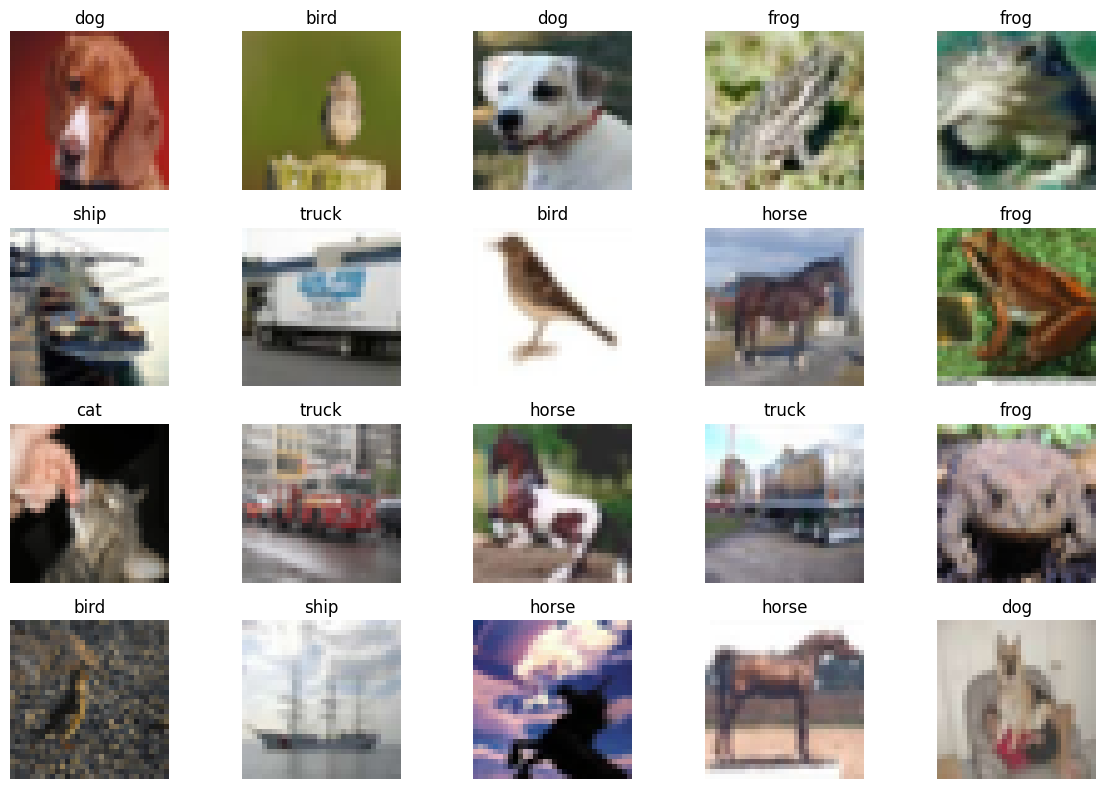

In [15]:
number_of_images = 20

random_indices = np.random.choice(
    len(x_train),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(12, 8))

for position, image_index in enumerate(random_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_train[image_index])

    label = y_train[image_index][0]

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

## **4.2 Classes Distripution**

In [16]:
unique_labels, class_counts = np.unique(
    y_train,
    return_counts=True
)

print("Training class distribution:\n")

for label, count in zip(unique_labels, class_counts):
    print(f"{label} - {class_names[label]}: {count} images")

Training class distribution:

0 - airplane: 5000 images
1 - automobile: 5000 images
2 - bird: 5000 images
3 - cat: 5000 images
4 - deer: 5000 images
5 - dog: 5000 images
6 - frog: 5000 images
7 - horse: 5000 images
8 - ship: 5000 images
9 - truck: 5000 images


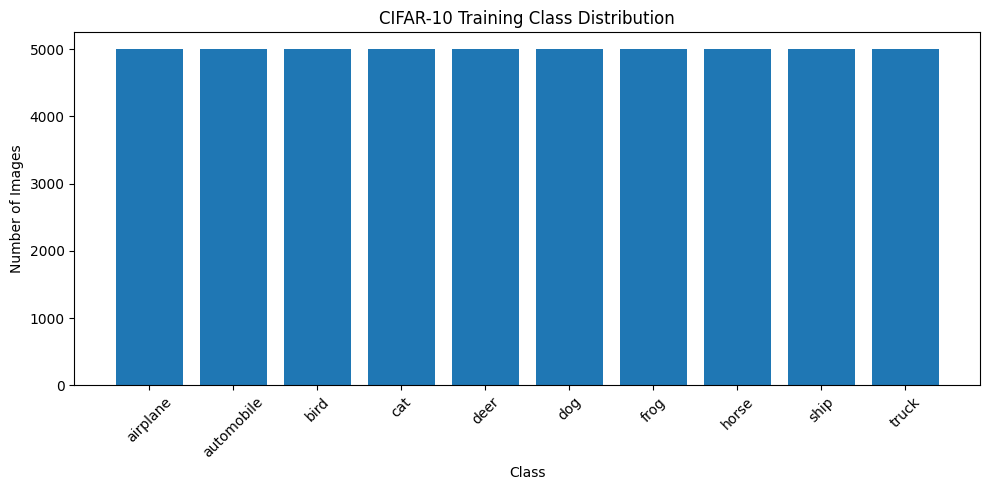

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***5. Data Preprocessing***

In [ ]:
x_train_original = x_train.copy()
x_test_original = x_test.copy()

y_train_original = y_train.copy()
y_test_original = y_test.copy()

## **5.1 Normalization & change dtype**

In [ ]:
x_train=x_train.astype('float32')
y_train=y_train.astype('float32')

x_train=x_train/255.0
y_train=y_train/255.0

## **5.2 Labels Reshape**

In [ ]:
x_test=x_test.reshape(-1)
x_train=x_train.reshape(-1)

## **5.3 Validation Set Separation**

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

# ***6. CNN Classification Model***

# ***7. Adam Training***

# ***8. SGD with Momentum Training***

# ***9. Optimizer Comparison***

# ***10. Autoencoder / VAE***

# ***11. Reconstruction Results***

# ***12. Generative Model***

# ***13. Generated Samples***

# ***14. Final Comparison***

# ***15. Final Reflection***